<a href="https://www.kaggle.com/code/lalit7881/playground-series-s6e7-end-to-end-ml-pipeline?scriptVersionId=333027163" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


## Loading dataset

In [2]:
from scipy.stats import gaussian_kde, pearsonr
import os
from matplotlib.patches import Patch

In [3]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "axes.linewidth": 2,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": "grey",
    "grid.alpha": 0.3,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
    "xtick.major.pad": 10,
    "ytick.major.pad": 6,
    "patch.edgecolor": "black",
    "patch.force_edgecolor": True,
})

In [4]:
health_condition_palette = {
    "fit": "#009E73",
    "at-risk": "#E69F00",
    "unhealthy": "#E24B4A",
}

gender_palette = {
    "male": "#378ADD",
    "female": "#D4537E",
    "other": "#7F77DD",
}

stress_level_palette = {
    "low": "#639922",
    "medium": "#BA7517",
    "high": "#E24B4A",
}

sleep_quality_palette = {
    "poor": "#E24B4A",
    "average": "#BA7517",
    "good": "#639922",
}

physical_activity_level_palette = {
    "sedentary": "#B5D4F4",
    "moderate": "#378ADD",
    "active": "#185FA5",
}

diet_type_palette = {
    "non-veg": "#C0504D",
    "balanced": "#AC8A53",
    "veg": "#97C459",
}

smoking_alcohol_palette = {
    "no": "#639922",
    "occasional": "#BA7517",
    "yes": "#E24B4A",
}

In [5]:
def annotate_counts(ax, total):
    for p in ax.patches:
        if (count := p.get_height()) == 0:
            continue
        ax.annotate(
            f"{int(count)}({count / total:.1%})",
            (p.get_x() + p.get_width() / 2, count),
            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points",
        )

def style_axis(ax):
    ax.spines["left"].set_visible(False)
    return ax

def plot_count(
    data_frame, col, palette, order=None, ax=None,
    yticks=None, hue=None, hue_order=None, annotate=True, legend=False,
):
    order = order or list(palette.keys())
    sns.countplot(
        x=col, data=data_frame, order=order,
        hue=hue or col, hue_order=hue_order, palette=palette,
        legend=bool(legend), ax=ax,
    )
    if annotate:
        annotate_counts(ax, len(data_frame))
    if yticks is not None:
        ax.set_yticks(yticks)
    if legend:
        ax.legend(title=legend)
    return style_axis(ax)


def numeric_pair_grid(
    data, features, hue="health_condition", palette=health_condition_palette,
    hue_order=None, sample=False, figsize=None, seed=0,
):
    n = len(features)
    plot_df = data.sample(min(sample, len(data)), random_state=seed) if sample else data
    fig, axes = plt.subplots(n, n, figsize=figsize or (2.6 * n, 2.6 * n))

    for i, yf in enumerate(features):
        for j, xf in enumerate(features):
            ax = axes[i, j]
            if i == j:
                sns.kdeplot(x=xf, data=data, hue=hue, hue_order=hue_order,
                            palette=palette, fill=True, alpha=0.6, legend=False, ax=ax)
            else:
                sns.scatterplot(x=xf, y=yf, data=plot_df, hue=hue, hue_order=hue_order,
                                palette=palette, s=8, alpha=0.4, edgecolor="none",
                                legend=False, ax=ax)
                r, _ = pearsonr(*data[[xf, yf]].dropna().to_numpy().T)
                ax.legend([f"$r = {r:.2f}$"], handlelength=0, handletextpad=0,
                          loc="upper right", fontsize=8, framealpha=0.7)
            ax.set_xlabel(xf if i == n - 1 else "")
            ax.set_ylabel(yf if j == 0 else "")
            ax.tick_params(labelsize=8)

    order = hue_order or list(data[hue].dropna().unique())
    handles = [plt.Line2D([0], [0], marker="o", ls="", color=palette[c], label=c)
               for c in order]
    fig.legend(handles=handles, title=hue, loc="upper right", bbox_to_anchor=(1.0, 1.0))
    fig.tight_layout()
    return fig


def plot_numeric_dist(
    data_frame, col, ax, hue=None, hue_order=None,
    palette=None, show_mean_line=True, alpha=0.9,
):
    if hue is None:
        mu, sigma = data_frame[col].mean(), data_frame[col].std()
        labels = [f"$\\mu={mu:.2f}$, $\\sigma={sigma:.2f}$"]
    else:
        hue_order = hue_order or list(data_frame[hue].dropna().unique())
        stats = data_frame.groupby(hue)[col].agg(["mean", "std"])
        labels = [f"{c}  ($\\mu={stats.loc[c, 'mean']:.2f}$, $\\sigma={stats.loc[c, 'std']:.2f}$)"
                  for c in hue_order]

    sns.kdeplot(x=col, data=data_frame, hue=hue,
                hue_order=hue_order if hue else None,
                palette=palette if hue else None,
                fill=True, alpha=alpha, edgecolor="black", ax=ax)

    if hue is None:
        if show_mean_line:
            peak = gaussian_kde(data_frame[col].dropna())(mu)[0]
            ax.vlines(mu, 0, peak, color="black", ls="--", lw=1.5)
        ax.legend(labels, handlelength=0, handletextpad=0)
    else:
        ax.legend(ax.get_legend().legend_handles, labels, title=hue)

    return style_axis(ax)

In [6]:
data_dir = "/kaggle/input/competitions/playground-series-s6e7"
train_path = os.path.join(data_dir, "train.csv")
train = pd.read_csv(train_path)

test_path = os.path.join(data_dir, "test.csv")
test = pd.read_csv(test_path)

sample_submission_path = os.path.join(data_dir, "sample_submission.csv")
sample_submission = pd.read_csv(sample_submission_path)

In [7]:
train

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [8]:
test

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [9]:
general_stats = train.describe(include="all").transpose()
general_stats

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,690088.0,NaN,NaN,NaN,345043.5,199211.39062,0.0,172521.75,345043.5,517565.25,690087.0
health_condition,690088,3,at-risk,592561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_duration,614089.0,NaN,NaN,NaN,6.992597,1.215407,3.0,6.16,6.99,7.81,10.0
heart_rate,682255.0,NaN,NaN,NaN,75.096504,8.175106,50.0,69.4,75.1,80.7,107.7
bmi,676190.0,NaN,NaN,NaN,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,NaN,NaN,NaN,2226.084931,347.532098,1200.0,2053.0,2241.0,2456.0,3580.0
step_count,676172.0,NaN,NaN,NaN,8615.95305,3929.399831,1002.0,5389.0,8856.0,12114.0,14999.0
exercise_duration,683187.0,NaN,NaN,NaN,38.751456,14.742189,0.0,29.2,39.4,49.4,99.8
water_intake,646611.0,NaN,NaN,NaN,2.188542,0.518489,0.5,1.84,2.17,2.5,4.72
diet_type,683187,3,veg,231432,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
id_column = "id"
numerical_features = [
    "sleep_duration", "heart_rate", "bmi", "calorie_expenditure", 
    "step_count", "exercise_duration", "water_intake",
]
ordinal_features = ["stress_level", "sleep_quality", "physical_activity_level"]
categorical_features = ["diet_type", "smoking_alcohol", "gender"]
target_column = "health_condition"

## EDA

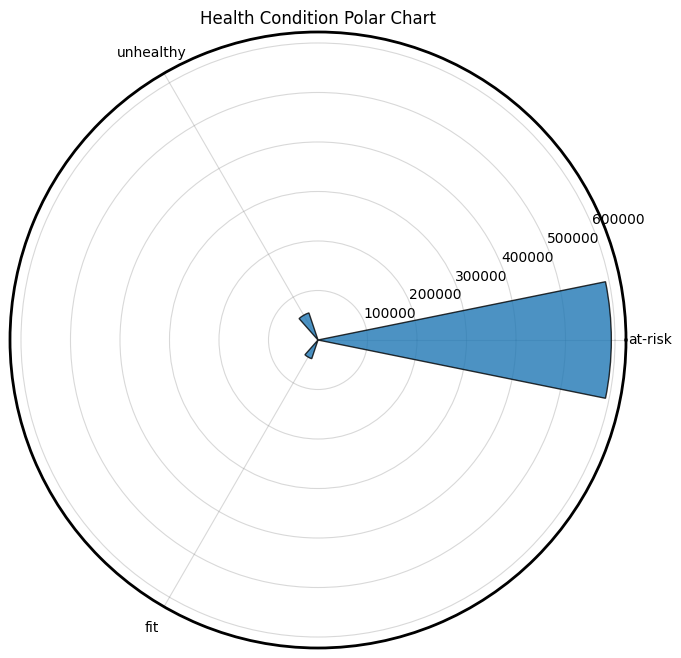

In [11]:
counts = train["health_condition"].value_counts()

theta = np.linspace(
    0,
    2*np.pi,
    len(counts),
    endpoint=False
)

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

bars = ax.bar(
    theta,
    counts.values,
    width=0.4,
    alpha=0.8
)

ax.set_xticks(theta)
ax.set_xticklabels(counts.index)

plt.title("Health Condition Polar Chart")

plt.show()

In [12]:
feature = "gender"
target = "health_condition"

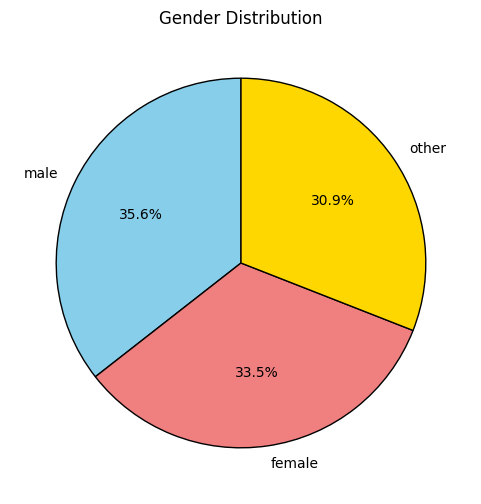

In [13]:
gender_counts = train[feature].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","lightcoral","gold","lightgreen"]
)

plt.title("Gender Distribution")
plt.show()

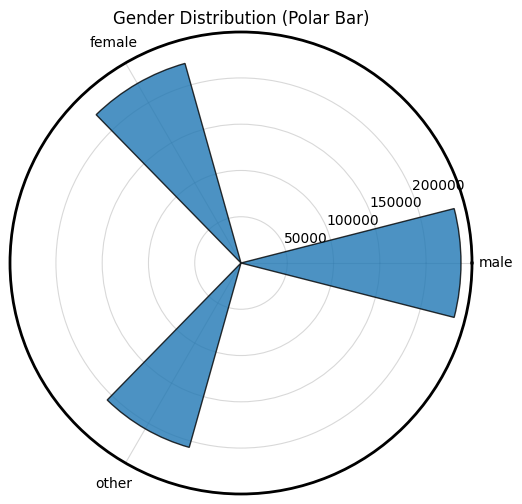

In [14]:
import numpy as np

counts = train[feature].value_counts()

theta = np.linspace(
    0,
    2*np.pi,
    len(counts),
    endpoint=False
)

radii = counts.values

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

ax.bar(
    theta,
    radii,
    width=0.5,
    alpha=0.8
)

ax.set_xticks(theta)
ax.set_xticklabels(counts.index)

plt.title("Gender Distribution (Polar Bar)")
plt.show()

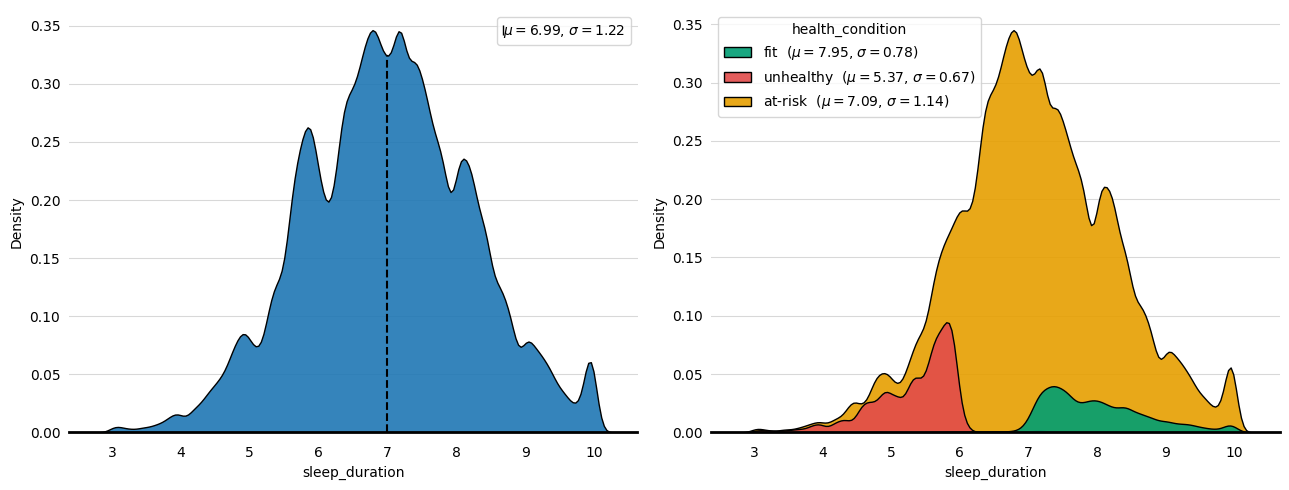

In [15]:
feature = "sleep_duration"

figure = plt.figure(figsize=(13, 5))

ax = figure.add_subplot(1, 2, 1)
plot_numeric_dist(
    data_frame=train,
    col=feature,
    ax=ax,
)

target_vs_feature_ax = figure.add_subplot(1, 2, 2)
plot_numeric_dist(
    data_frame=train,
    col=feature,
    hue="health_condition",
    hue_order=["fit", "unhealthy", "at-risk"],
    palette=health_condition_palette,
    ax=target_vs_feature_ax,
)

figure.tight_layout()
figure.show()


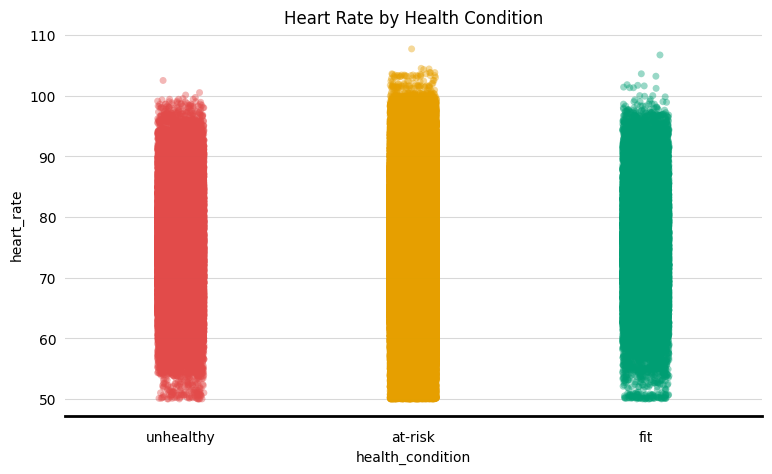

In [16]:
plt.figure(figsize=(9,5))

sns.stripplot(
    data=train,
    x="health_condition",
    y="heart_rate",
    palette=health_condition_palette,
    alpha=0.4
)

plt.title("Heart Rate by Health Condition")

plt.show()

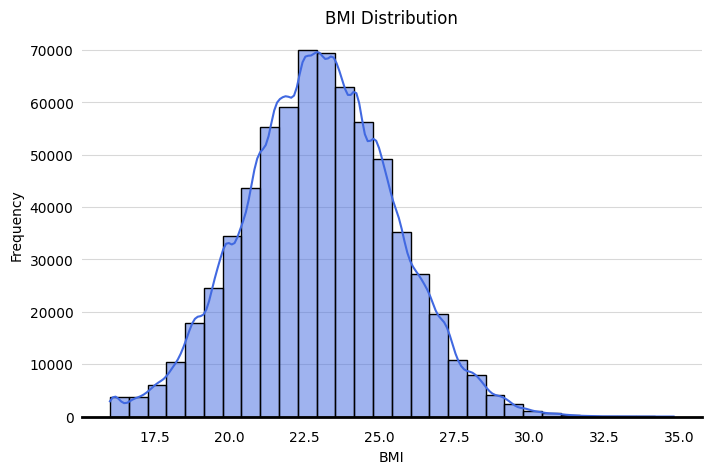

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=train,
    x="bmi",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

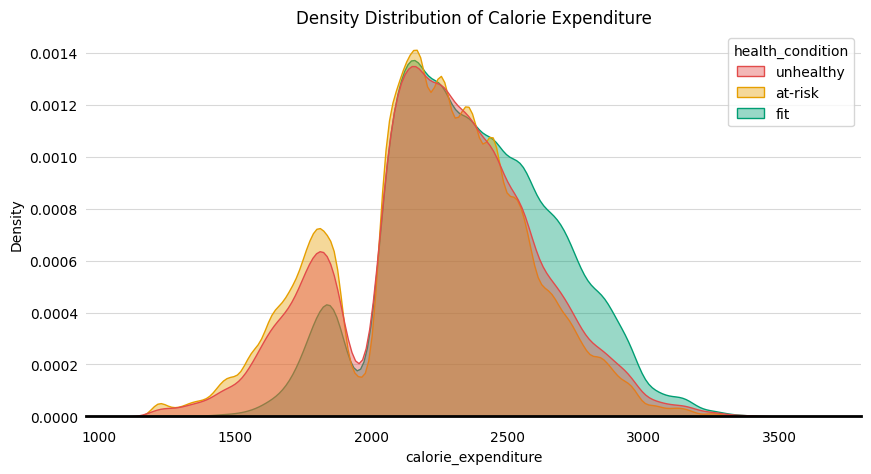

In [18]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=train,
    x="calorie_expenditure",
    hue="health_condition",
    fill=True,
    alpha=0.4,
    common_norm=False,
    palette=health_condition_palette
)

plt.title("Density Distribution of Calorie Expenditure")

plt.show()

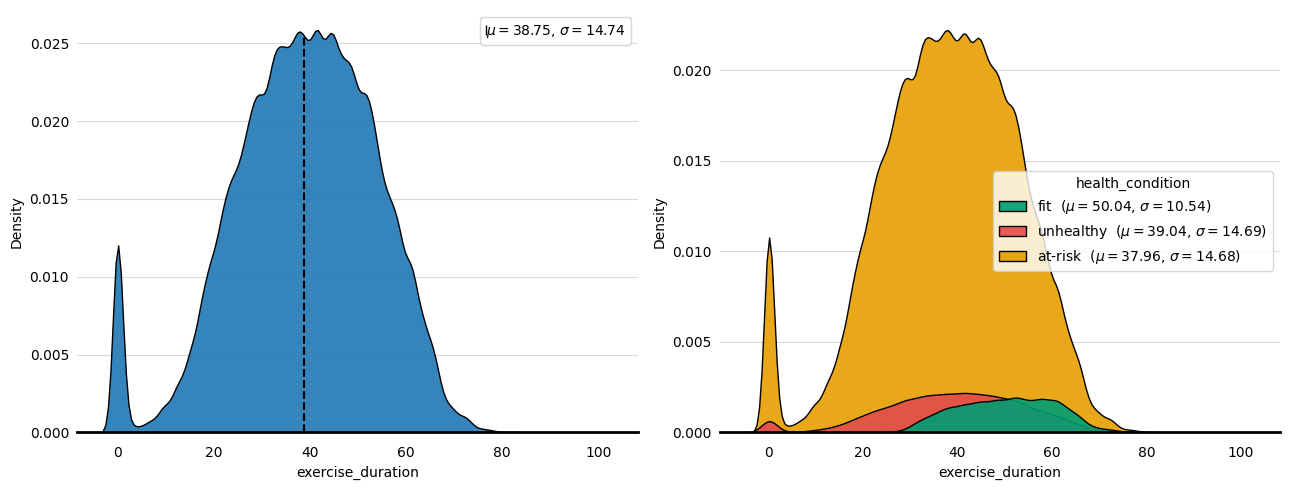

In [19]:
feature = "exercise_duration"

figure = plt.figure(figsize=(13, 5))

ax = figure.add_subplot(1, 2, 1)
plot_numeric_dist(
    data_frame=train,
    col=feature,
    ax=ax,
)

target_vs_feature_ax = figure.add_subplot(1, 2, 2)
plot_numeric_dist(
    data_frame=train,
    col=feature,
    hue="health_condition",
    hue_order=["fit", "unhealthy", "at-risk"],
    palette=health_condition_palette,
    ax=target_vs_feature_ax,
)

figure.tight_layout()
figure.show()

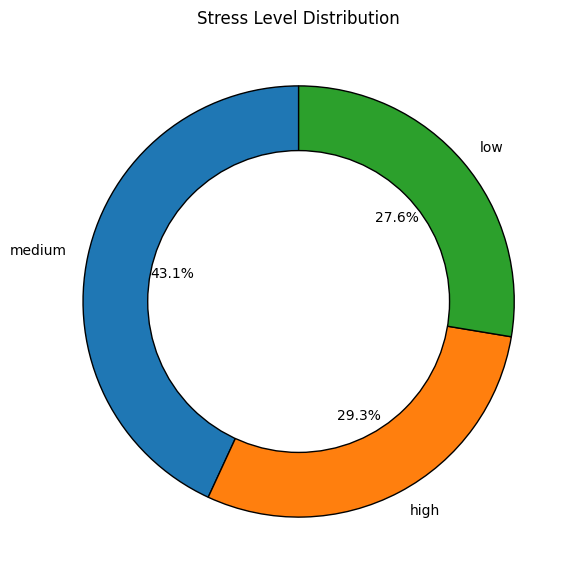

In [20]:
fig, ax = plt.subplots(figsize=(7,7))

counts = train["stress_level"].value_counts()

ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig.gca().add_artist(centre_circle)

plt.title("Stress Level Distribution")

plt.show()

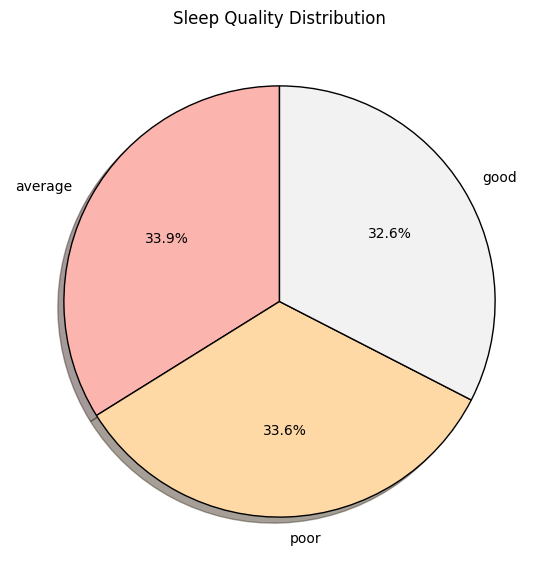

In [21]:
plt.figure(figsize=(7,7))

train["sleep_quality"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    colormap="Pastel1"
)

plt.ylabel("")
plt.title("Sleep Quality Distribution")

plt.show()

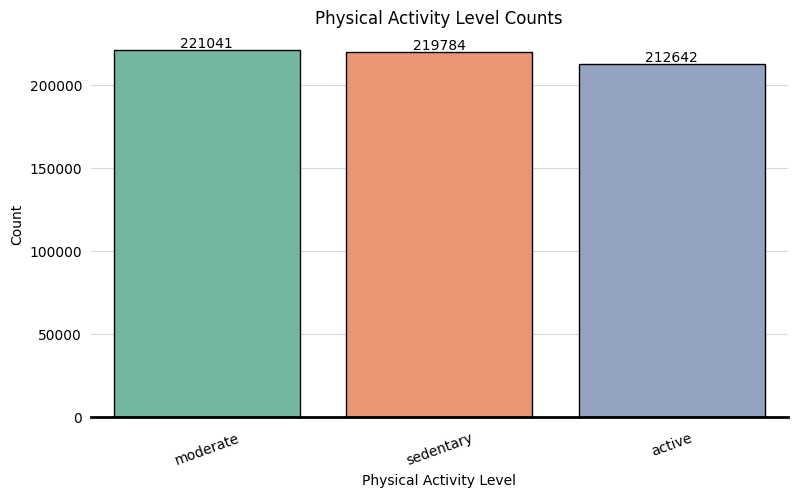

In [22]:
plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=train,
    x="physical_activity_level",
    palette="Set2",
    order=train["physical_activity_level"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Physical Activity Level Counts")
plt.xlabel("Physical Activity Level")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.show()

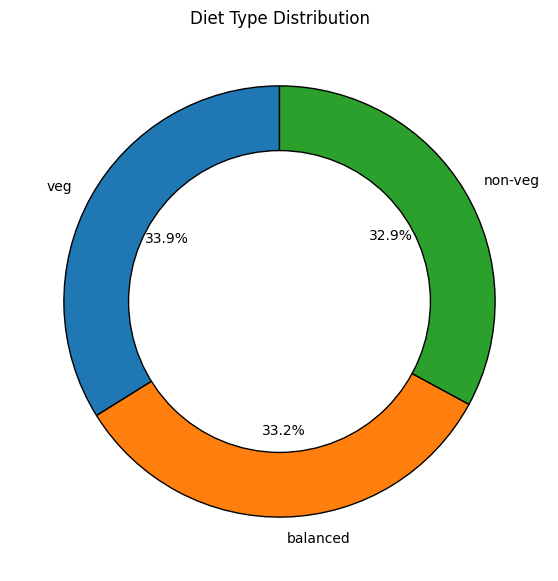

In [23]:
fig, ax = plt.subplots(figsize=(7,7))

counts = train["diet_type"].value_counts()

ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig.gca().add_artist(centre_circle)

plt.title("Diet Type Distribution")

plt.show()

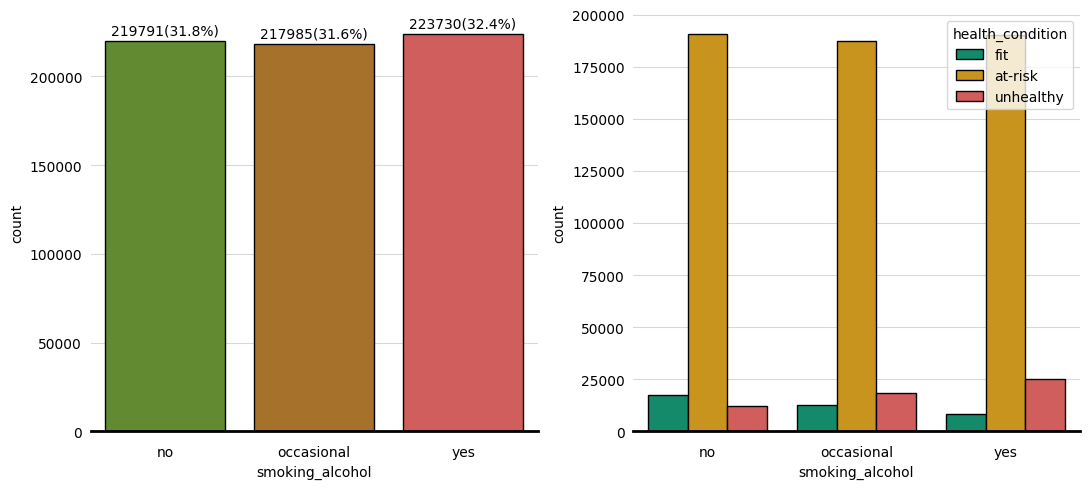

In [24]:
feature = "smoking_alcohol"
feature_palette = smoking_alcohol_palette

figure = plt.figure(figsize=(11, 5))

ax = figure.add_subplot(1, 2, 1)
plot_count(
    data_frame=train, 
    col=feature, 
    palette=feature_palette,
    ax=ax,
)

feature_vs_target_ax = figure.add_subplot(1, 2, 2)
plot_count(
    data_frame=train, 
    col=feature, 
    hue="health_condition",
    order=list(feature_palette.keys()),
    hue_order=list(health_condition_palette.keys()),
    palette=health_condition_palette,
    ax=feature_vs_target_ax,
    annotate=False,
    legend="health_condition",
)

figure.tight_layout()
figure.show()

In [25]:
missing_values_count = (train.isnull().sum(axis=0) / train.shape[0]) * 100
missing_values_count = missing_values_count.sort_values(ascending=False)

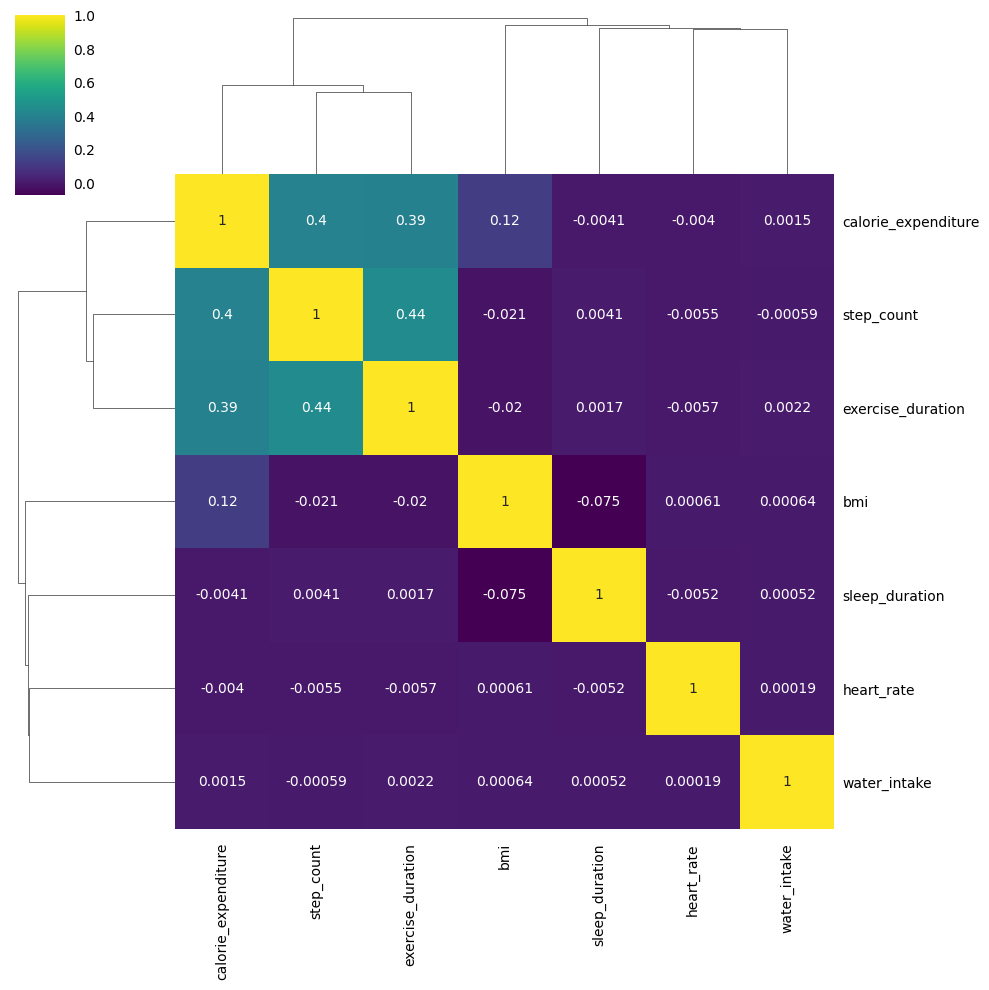

In [26]:
corr = train[numerical_features].corr()

sns.clustermap(
    corr,
    annot=True,
    cmap="viridis",
    figsize=(10,10)
)

plt.show()

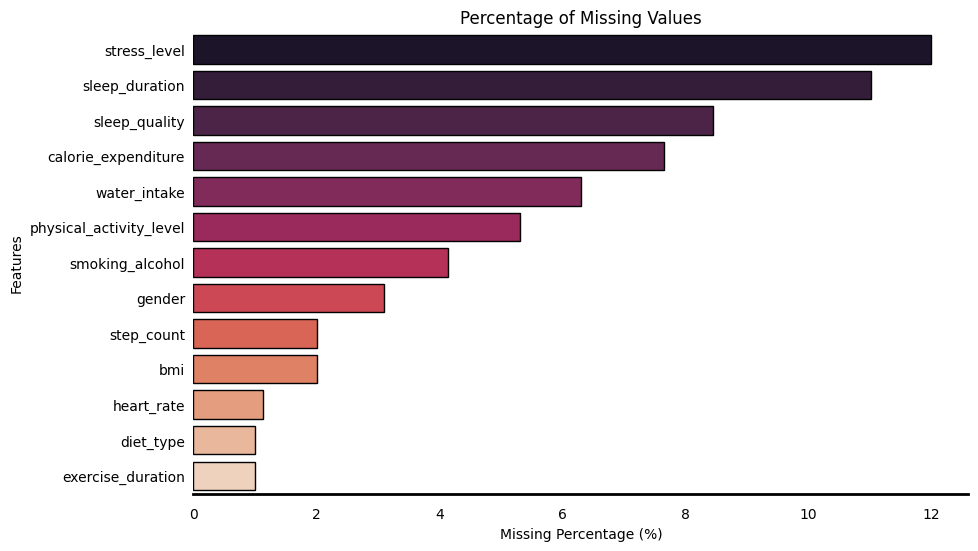

In [27]:
missing_percent = (train.isnull().mean()*100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index,
    palette="rocket"
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")

plt.title("Percentage of Missing Values")

plt.show()

In [28]:
columns = set(train.columns) - {"id", "health_condition"}
duplicates = train[train.duplicated(subset=columns)]
duplicates

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


## Feature engineering

In [29]:
from sklearn.metrics import balanced_accuracy_score

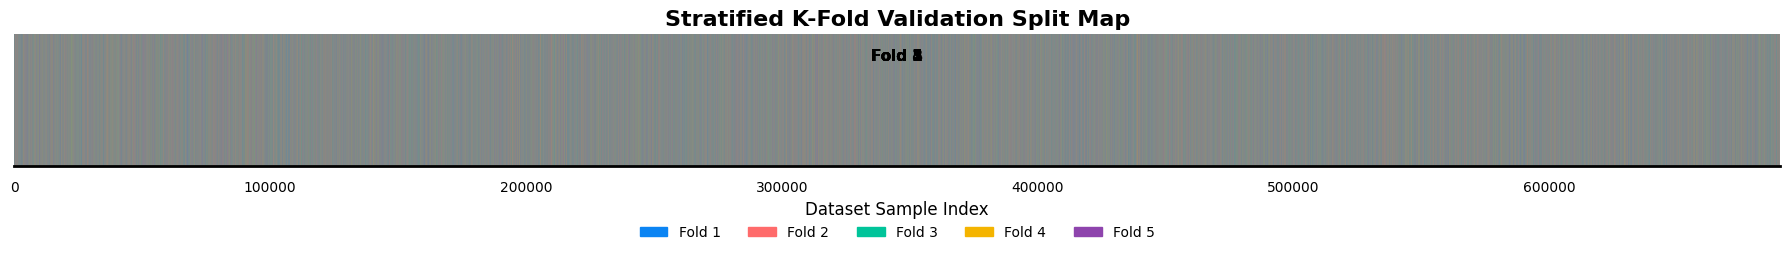

In [30]:
from matplotlib.colors import ListedColormap
from sklearn.model_selection import StratifiedKFold

# -------------------------------
# Stratified K-Fold
# -------------------------------
num_folds = 5
cv = StratifiedKFold(
    n_splits=num_folds,
    shuffle=True,
    random_state=13
)

# Create fold assignment array
fold_assignment = np.zeros(len(train), dtype=int)

for fold, (_, valid_idx) in enumerate(cv.split(train, train[target_column])):
    fold_assignment[valid_idx] = fold

# -------------------------------
# Unique Fold Visualization
# -------------------------------
fig, ax = plt.subplots(figsize=(18, 3))

colors = [
    "#0B84F3",
    "#FF6B6B",
    "#00C49A",
    "#F4B400",
    "#8E44AD"
]

cmap = ListedColormap(colors)

ax.imshow(
    fold_assignment.reshape(1, -1),
    aspect="auto",
    cmap=cmap
)

# Fold boundaries
for fold, (_, valid_idx) in enumerate(cv.split(train, train[target_column])):
    start = valid_idx.min()
    end = valid_idx.max()
    ax.text(
        (start + end) / 2,
        -0.3,
        f"Fold {fold+1}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_yticks([])
ax.set_xlabel("Dataset Sample Index", fontsize=12)
ax.set_title("Stratified K-Fold Validation Split Map", fontsize=16, fontweight="bold")

# Legend
handles = [
    plt.Rectangle((0,0),1,1,color=colors[i],label=f"Fold {i+1}")
    for i in range(num_folds)
]
ax.legend(
    handles=handles,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5,-0.35),
    frameon=False
)

plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold

num_folds = 5
shuffle = True
random_seed = 13

cv_strategy = StratifiedKFold(
    n_splits=num_folds, 
    shuffle=shuffle, 
    random_state=random_seed,
)
folds = list(cv_strategy.split(
    X=train, y=train[target_column].values, groups=None,
))

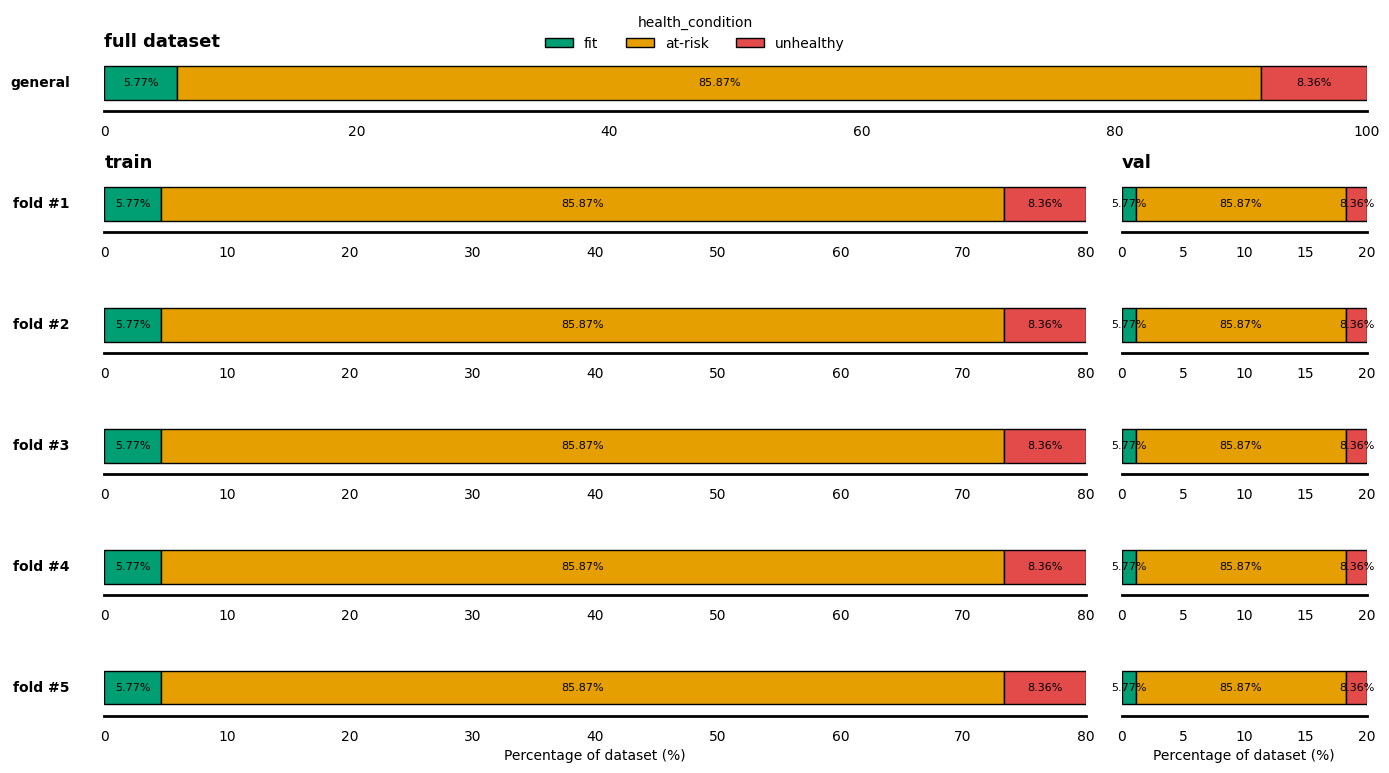

In [32]:
compute_target_dist = lambda data, target_column: (data[target_column].value_counts() / data.shape[0]) * 100
general_target_dist = compute_target_dist(train, target_column)
dists = [general_target_dist]
for fold, (train_indices, val_indices) in enumerate(folds, 1):
    fold_train_target_dist = compute_target_dist(train.iloc[train_indices], target_column)
    fold_val_target_dist = compute_target_dist(train.iloc[val_indices], target_column)
    dists.extend([fold_train_target_dist, fold_val_target_dist])
dists = pd.DataFrame(
    dists,
    index=(
        ["general"] +
        [x
        for k in range(1, num_folds + 1)
        for x in (f"fold_{k}_train", f"fold_{k}_val")
        ]
    ),
)

class_order = ["fit", "at-risk", "unhealthy"]
train_max = 100 - 100 / num_folds
val_max = 100 / num_folds

fig = plt.figure(figsize=(14, 1.1 * (num_folds + 1) + 1))
gs = fig.add_gridspec(num_folds + 1, 2, width_ratios=[train_max, val_max])

ax_general = fig.add_subplot(gs[0, :])
axes = [[fig.add_subplot(gs[r, 0]), fig.add_subplot(gs[r, 1])] for r in range(1, num_folds + 1)]

def draw_bar(ax, row_name, total):
    left = 0.0
    for cls in class_order:
        pct = dists.loc[row_name, cls]
        w = pct / 100 * total
        ax.barh(0, w, left=left, height=0.6,
                color=health_condition_palette[cls], edgecolor="black")
        ax.text(left + w / 2, 0, f"{pct:.2f}%",
                    va="center", ha="center", fontsize=8)
        left += w
    ax.set_xlim(0, total)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.tick_params(length=0)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)

draw_bar(ax_general, "general", 100)
ax_general.set_ylabel("general", rotation=0, ha="right",
                      va="center", fontweight="bold", labelpad=25)
ax_general.set_title("full dataset", fontsize=13, fontweight="bold", loc="left")

for i in range(num_folds):
    draw_bar(axes[i][0], f"fold_{i + 1}_train", train_max)
    draw_bar(axes[i][1], f"fold_{i + 1}_val", val_max)
    axes[i][0].set_ylabel(f"fold #{i + 1}", rotation=0, ha="right",
                          va="center", fontweight="bold", labelpad=25)

axes[0][0].set_title("train", fontsize=13, fontweight="bold", loc="left")
axes[0][1].set_title("val", fontsize=13, fontweight="bold", loc="left")
axes[-1][0].set_xlabel("Percentage of dataset (%)")
axes[-1][1].set_xlabel("Percentage of dataset (%)")

handles = [Patch(facecolor=health_condition_palette[c], edgecolor="black", label=c)
           for c in class_order]
fig.legend(handles=handles, title="health_condition", ncol=3,
           loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

fig.tight_layout()
fig.show()

In [33]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/playground-series-s6e7
    sample_submission.csv
    train.csv
    test.csv


In [34]:
%who

ListedColormap	 Patch	 StratifiedKFold	 annotate_counts	 ax	 ax_general	 axes	 balanced_accuracy_score	 bars	 
categorical_features	 centre_circle	 class_order	 cmap	 colors	 columns	 compute_target_dist	 container	 corr	 
counts	 cv	 cv_strategy	 data_dir	 diet_type_palette	 dirname	 dirs	 dists	 draw_bar	 
duplicates	 end	 f	 feature	 feature_palette	 feature_vs_target_ax	 fig	 figure	 filename	 
filenames	 files	 fold	 fold_assignment	 fold_train_target_dist	 fold_val_target_dist	 folds	 gaussian_kde	 gender_counts	 
gender_palette	 general_stats	 general_target_dist	 gs	 handles	 health_condition_palette	 i	 id_column	 kagglehub	 
missing_percent	 missing_values_count	 np	 num_folds	 numeric_pair_grid	 numerical_features	 ordinal_features	 os	 pd	 
pearsonr	 physical_activity_level_palette	 plot_count	 plot_numeric_dist	 plt	 radii	 random_seed	 root	 sample_submission	 
sample_submission_path	 shuffle	 sleep_quality_palette	 smoking_alcohol_palette	 sns	 start	 stress_level_palett

In [35]:
submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
)

submission.to_csv("submission.csv", index=False)

print(submission.head())

       id health_condition
0  690088          at-risk
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092          at-risk


## Thank you..pls upvote!!!!!!!!!!!!!